# Figure 5 -- EEG Motor Imagery Benchmark

Reproduces **Figure 5** of the arxiv_v2 manuscript
(`paper/sections_arxiv_v2/3_experiments_2.tex`, `fig:reach`): 4 panels (A-D)
benchmarking SISR against CSP+LDA on the BCI Competition IV dataset 2a
(BNCI2014_001, 9-subject motor-imagery EEG via MOABB), at
$(\lambda, \eta_u, \eta_p) = (1000, 3\times10^{-5}, 0.01)$.

- (A) Held-out 4-way motor-imagery accuracy per subject, SISR vs. CSP+LDA
  (bars: mean $\pm$ std across 5 seeds; asterisks: per-subject one-sample
  $t$-test, $p<0.05$; "Combined": paired $t$-test across the 9 subjects' means).
- (B) Per-subject beta-band (13-30Hz) classifier weight vs. test accuracy.
- (C) SISR's presence-classifier weight per frequency bin (mean $\pm$ std
  across subjects), one row per motor-imagery class.
- (D) Per-trial beta-band power in the recovered source during the
  motor-imagery period, ordered/colored by held-out accuracy.

**MOABB** (the EEG dataset loader) needs numpy>=2, which conflicts with this
project's main environment, so any step that loads raw per-subject EEG data
shells out to a separate `moab` conda env (`/opt/anaconda3/envs/moab/bin/python3`)
and caches the result under `results/eeg_per_subject_data/` -- after the
first run, every subsequent run reads that cache directly and needs no
`moab` env access at all.

This notebook regenerates every panel from raw data: each cell below fetches
the relevant per-subject EEG data and runs the actual SISR (`multi_ica`) or
CSP+LDA/TangentSpace+LogReg fit -- not just a cache read -- then caches the
result. Every step is a fast no-op if its `results/.../*.pt` cache already
exists (all of them do, as shipped in this repo); a missing cache makes that
step retrain from scratch, and the SISR fits are genuinely expensive: **45
(subject, seed) combinations at 30,000 iterations each**.

In [ ]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from joblib import Parallel, delayed
from scipy import stats
from scipy.signal.windows import tukey
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

PROJECT_ROOT = Path.cwd().resolve().parent  # notebook lives in notebooks/, one level under the repo root
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from multiica.data import create_hilbert_matrix, normalize_energy, generate_multioutput_simulated_4
from multiica.ica_no_reorder import multi_ica
from multiica.models import SpectrogramSharedBinPresenceMLP
from multiica.utils import compute_amari_distance, OptimizationError

# All generated/cached data lives under notebooks/output/ (not results/ or
# figures/ at the repo root), matching this repo's existing notebooks/output
# convention.
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT = OUTPUT_DIR / "results"


def remove_spines(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# Figure 5: EEG Motor Imagery Benchmark (paper/sections_arxiv_v2/3_experiments_2.tex,
# fig:reach). 4 panels (A-D), on BNCI2014_001 motor-imagery EEG via MOABB.
# ═════════════════════════════════════════════════════════════════════════════

MOAB_PYTHON = "/opt/anaconda3/envs/moab/bin/python3"
EEG_SUBJECT_DATA_DIR = RESULTS_ROOT / "eeg_per_subject_data"
EEG_SUBJECT_DATA_DIR.mkdir(parents=True, exist_ok=True)

EEG_SUBJECTS = list(range(1, 10))
EEG_SEEDS = [42, 43, 44, 45, 46]
EEG_SAMPLE_RATE = 250  # Hz, fixed by BNCI2014_001
EEG_BASELINE_SECONDS = 2.0
EEG_MI_SECONDS = 4.0
EEG_BASELINE_SAMPLES = int(round(EEG_BASELINE_SECONDS * EEG_SAMPLE_RATE))
EEG_N_FFT, EEG_WINDOW_LENGTH, EEG_HOP_LENGTH = 64, 50, 15
EEG_MAX_ABS_WEIGHT = 1.0
EEG_TIME_HALFBANDWIDTH_PRODUCT = 2.0
EEG_LAM, EEG_LR_UNMIX, EEG_LR_MODEL = 1000, 3e-5, 0.01
EEG_MAX_ITER = 30000
EEG_BETA_LOW, EEG_BETA_HIGH = 13.0, 30.0  # Hz, standard beta band
EEG_CLASS_LABELS = {"feet": "Feet", "left_hand": "Left hand", "right_hand": "Right hand", "tongue": "Tongue"}


def fetch_eeg_subject_data(subject, retrain=False):
    """BNCI2014_001 motor-imagery data for one subject, tmin=0.0 (includes
    the 2s pre-cue baseline). Shells out to the 'moab' conda env for the
    actual MOABB load (moabb needs numpy>=2, which conflicts with this
    project's main environment) -- the load logic below is inlined
    directly (copied from analysis scripts/neural moab/neural_moab_baseline_presence.py's
    generate_data() in the supervised_source_decomposition repo), so this
    notebook has no dependency on that external script. Caches the result
    so subsequent calls -- even from a fresh notebook run -- never need the
    moab env again unless this specific subject's cache is deleted."""
    cache_path = EEG_SUBJECT_DATA_DIR / f"subject_{subject}.pt"
    if cache_path.exists() and not retrain:
        return torch.load(cache_path, weights_only=False)

    print(f"  Shelling out to the 'moab' conda env to load subject {subject}'s EEG data via MOABB...")
    script = f"""
import numpy as np
import torch
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

SAMPLE_RATE = {EEG_SAMPLE_RATE}
BASELINE_SECONDS = {EEG_BASELINE_SECONDS}
MI_SECONDS = {EEG_MI_SECONDS}

dataset = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, tmin=0.0, tmax=BASELINE_SECONDS + MI_SECONDS)
X, y_str, meta = paradigm.get_data(dataset=dataset, subjects=[{subject}])
epochs, _, _ = paradigm.get_data(dataset=dataset, subjects=[{subject}], return_epochs=True)
info = epochs.info

classes = sorted(np.unique(y_str))
class_to_idx = {{c: i for i, c in enumerate(classes)}}
y = np.array([class_to_idx[c] for c in y_str], dtype=np.int64)

train_mask = meta["session"].to_numpy() == "0train"
test_mask = meta["session"].to_numpy() == "1test"
subject_all = meta["subject"].to_numpy()

x_train, y_train = X[train_mask].astype(np.float32), y[train_mask]
x_test, y_test = X[test_mask].astype(np.float32), y[test_mask]
subject_train, subject_test = subject_all[train_mask], subject_all[test_mask]

N, C, T = x_train.shape
data = dict(
    x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test,
    subject_train=subject_train, subject_test=subject_test,
    classes=classes, N=N, C=C, T=T, info=info,
)
torch.save(data, {str(cache_path)!r})
"""
    # Explicitly override MPLBACKEND: subprocess.run() inherits this
    # kernel's environment, and Jupyter sets MPLBACKEND to its own
    # inline backend -- a value the moab env's matplotlib (a different
    # version) doesn't recognize, which breaks mne's import chain. The
    # subprocess only loads data (no plotting), so "Agg" is always safe.
    env = {**os.environ, "MPLBACKEND": "Agg"}
    subprocess.run([MOAB_PYTHON, "-c", script], check=True, env=env)
    return torch.load(cache_path, weights_only=False)


def make_eeg_model(T):
    return SpectrogramSharedBinPresenceMLP(
        1, n_fft=EEG_N_FFT, window_length=EEG_WINDOW_LENGTH, hop_length=EEG_HOP_LENGTH,
        n_timepoints=T, bottleneck=True, sample_rate=EEG_SAMPLE_RATE,
        freq_cutoff=EEG_SAMPLE_RATE / 2,  # Nyquist at 250Hz sample rate
        max_abs_weight=EEG_MAX_ABS_WEIGHT,
        time_halfbandwidth_product=EEG_TIME_HALFBANDWIDTH_PRODUCT,
        pos_weight="auto",
    )


def make_eeg_presence_labels(y, n_classes, n_time_bins, T):
    """Per-time-bin one-vs-rest presence target: for source c, 1 during the
    MI portion of trials whose true class is c, 0 everywhere else."""
    bin_size = T / n_time_bins
    bin_centers = (np.arange(n_time_bins) + 0.5) * bin_size
    is_mi_bin = (bin_centers >= EEG_BASELINE_SAMPLES).astype(np.float32)
    presence = np.zeros((len(y), n_classes, n_time_bins), dtype=np.float32)
    for c in range(n_classes):
        match = (y == c).astype(np.float32)
        presence[:, c, :] = np.outer(match, is_mi_bin)
    return presence


def _eeg_mean_presence_score_features(data, output):
    n_classes = len(data["classes"])
    n_time = output["n_time"]
    W = output["unmixing_matrix"]
    W = W.numpy() if torch.is_tensor(W) else np.asarray(W)
    bin_size = data["T"] / n_time
    bin_centers = (np.arange(n_time) + 0.5) * bin_size
    mi_bin_mask = bin_centers >= EEG_BASELINE_SAMPLES

    def make(x_data):
        feats = np.zeros((x_data.shape[0], n_classes), dtype=np.float32)
        x_t = torch.as_tensor(x_data)
        for c in range(n_classes):
            w_c = torch.as_tensor(W[c]).float()
            x_src = torch.einsum("c,bct->bt", w_c, x_t).unsqueeze(1)
            pred = output["models"][c].predict(x_src).numpy()
            feats[:, c] = pred[:, mi_bin_mask].mean(axis=1)
        return feats

    return make(data["x_train"]), make(data["x_test"])


def eeg_fourway_accuracy(data, output):
    """4-way motor-imagery accuracy via an LDA readout on the 4 one-vs-rest
    presence-classifier scores (mean predicted presence during the MI
    period, one feature per class)."""
    X_train, X_test = _eeg_mean_presence_score_features(data, output)
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train, data["y_train"])
    y_pred = lda.predict(X_test)
    return float(np.mean(y_pred == data["y_test"]))


In [3]:
# ── Pipeline 1: per-subject CSP+LDA / TangentSpace+LogReg baselines ────────
# Backs panel A. Deterministic sklearn/pyriemann pipelines -- fast once the
# per-subject data itself is available.

EEG_BASELINES_RESULTS_PATH = RESULTS_ROOT / "fig4_per_subject" / "baselines_per_subject.pt"
EEG_BASELINES_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)


def _fit_eeg_baselines_per_subject(data):
    x_train = data["x_train"][:, :, EEG_BASELINE_SAMPLES:]
    x_test = data["x_test"][:, :, EEG_BASELINE_SAMPLES:]
    y_train, y_test = data["y_train"], data["y_test"]
    pipelines = {
        "CSP+LDA": make_pipeline(
            CSP(n_components=8, reg=None, log=True, norm_trace=False),
            LinearDiscriminantAnalysis(),
        ),
        "TangentSpace+LogReg": make_pipeline(
            Covariances(estimator="oas"),
            TangentSpace(metric="riemann"),
            LogisticRegression(max_iter=1000),
        ),
    }
    results = {}
    for name, pipeline in pipelines.items():
        pipeline.fit(x_train, y_train)
        results[name] = pipeline.score(x_test, y_test)
    return results


def fit_eeg_baselines_all_subjects(retrain=False):
    if EEG_BASELINES_RESULTS_PATH.exists() and not retrain:
        print(f"Loading cached per-subject baselines from {EEG_BASELINES_RESULTS_PATH}...")
        return torch.load(EEG_BASELINES_RESULTS_PATH, weights_only=False)

    results = {}
    for s in EEG_SUBJECTS:
        print(f"Fitting CSP+LDA / TangentSpace+LogReg for subject {s}...")
        data = fetch_eeg_subject_data(s)
        results[s] = _fit_eeg_baselines_per_subject(data)
        print(f"  subject {s}: {results[s]}")
    torch.save(results, EEG_BASELINES_RESULTS_PATH)
    print(f"  saved -> {EEG_BASELINES_RESULTS_PATH}")
    return results


In [4]:
# ── Pipeline 2: per-subject SISR (multi_ica) fits ──────────────────────────
# Backs panels A, B, C, D. 45 (subject, seed) combos at 30000 iterations
# each -- the expensive step if this cache is ever lost.

EEG_MICA_RESULTS_PATH = RESULTS_ROOT / "fig4_per_subject_lam1000_etau3e5_etap01_retrain" / "multi_ica_per_subject.pt"
EEG_MICA_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)


def _fit_eeg_multi_ica_one(subject, seed, data):
    n_classes = len(data["classes"])
    T, N = data["T"], data["N"]
    probe_model = make_eeg_model(T)
    n_time = probe_model.n_time
    presence_train = make_eeg_presence_labels(data["y_train"], n_classes, n_time, T)
    presence_test = make_eeg_presence_labels(data["y_test"], n_classes, n_time, T)

    try:
        models = [make_eeg_model(T) for _ in range(n_classes)]
        output = multi_ica(
            torch.as_tensor(data["x_train"]),
            labels=torch.as_tensor(presence_train),
            x_test=torch.as_tensor(data["x_test"]),
            labels_test=torch.as_tensor(presence_test),
            tasks=["regression"] * n_classes,
            models=models,
            batch_size_samples=min(64, T),
            batch_size_trials=min(200, N),
            lam=EEG_LAM,
            lr_unmix=EEG_LR_UNMIX,
            lr_model=EEG_LR_MODEL,
            max_iter=EEG_MAX_ITER,
            seed=seed,
            eval_iter=EEG_MAX_ITER,  # only need the final checkpoint
        )
    except OptimizationError as e:
        print(f"  subject={subject} seed={seed}: FAILED: {e}")
        return subject, seed, None

    output["n_time"] = n_time
    acc = eeg_fourway_accuracy(data, output)
    print(f"  subject={subject} seed={seed}: acc={acc:.4f}")
    return subject, seed, {
        "unmixing_matrix": output["unmixing_matrix"],
        "models": output["models"],
        "n_time": n_time,
        "accuracy": acc,
    }


def fit_eeg_multi_ica_per_subject(retrain=False, n_jobs=-1):
    existing = (
        torch.load(EEG_MICA_RESULTS_PATH, weights_only=False)
        if (EEG_MICA_RESULTS_PATH.exists() and not retrain) else {}
    )
    todo = [(s, seed) for s in EEG_SUBJECTS for seed in EEG_SEEDS if (s, seed) not in existing]
    if not todo:
        print(f"All {len(EEG_SUBJECTS) * len(EEG_SEEDS)} (subject, seed) combos already cached.")
        return existing

    print(f"Fitting {len(todo)}/{len(EEG_SUBJECTS) * len(EEG_SEEDS)} remaining (subject, seed) combos "
          f"as one flat joblib grid (n_jobs={n_jobs})...")
    needed_subjects = sorted({s for s, _ in todo})
    per_subject_data = {s: fetch_eeg_subject_data(s) for s in needed_subjects}

    chunk_size = os.cpu_count() or 12
    for i in range(0, len(todo), chunk_size):
        chunk = todo[i:i + chunk_size]
        print(f"  chunk {i // chunk_size + 1}/{-(-len(todo) // chunk_size)}: {chunk}")
        fitted = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(_fit_eeg_multi_ica_one)(s, seed, per_subject_data[s]) for s, seed in chunk
        )
        for s, seed, res in fitted:
            existing[(s, seed)] = res
        torch.save(existing, EEG_MICA_RESULTS_PATH)
        print(f"    saved progress ({len(existing)}/{len(EEG_SUBJECTS) * len(EEG_SEEDS)}) -> {EEG_MICA_RESULTS_PATH.name}")
    return existing


In [5]:
# ── Pipeline 3: per-trial beta-band power (panel D) ────────────────────────

EEG_BETA_POWER_CACHE_PATH = (
    OUTPUT_DIR / "figures" / "beta_power_per_trial_histogram_lam1000_etau3e5_etap01" / "per_trial_beta_power.pt"
)
EEG_BETA_POWER_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)


def _eeg_trial_beta_power(model, source_1d):
    """log10-power averaged over beta-band freq bins and the time axis, in
    the same feature space the classifier itself operates on."""
    x = torch.as_tensor(source_1d).float()
    tf = model._spectrogram(x)
    freq_axis = model.frequencies[model.freq_mask] if model.bottleneck else model.frequencies
    mask = (freq_axis >= EEG_BETA_LOW) & (freq_axis <= EEG_BETA_HIGH)
    beta_tf = tf[0, mask, :]
    return float(beta_tf.mean())


def fit_eeg_beta_power_per_trial(retrain=False):
    if EEG_BETA_POWER_CACHE_PATH.exists() and not retrain:
        print(f"Loading cached per-trial beta power from {EEG_BETA_POWER_CACHE_PATH}...")
        return torch.load(EEG_BETA_POWER_CACHE_PATH, weights_only=False)

    mica = torch.load(EEG_MICA_RESULTS_PATH, weights_only=False)
    cache = {}
    for s in EEG_SUBJECTS:
        print(f"Subject {s}...")
        seed_entries = [(seed, mica[(s, seed)]) for seed in EEG_SEEDS if mica.get((s, seed)) is not None]
        if not seed_entries:
            print("  all seeds diverged, skipping.")
            cache[s] = None
            continue

        data = fetch_eeg_subject_data(s)
        x_all = np.concatenate([data["x_train"], data["x_test"]], axis=0)
        seed, entry = max(seed_entries, key=lambda t: t[1]["accuracy"])
        W = np.asarray(entry["unmixing_matrix"])
        models = entry["models"]
        n_classes = len(models)

        per_trial_beta, per_trial_beta_baseline, per_trial_beta_mi = [], [], []
        for trial_idx in range(x_all.shape[0]):
            x_trial = x_all[trial_idx]
            x_trial_baseline = x_trial[:, :EEG_BASELINE_SAMPLES]
            x_trial_mi = x_trial[:, EEG_BASELINE_SAMPLES:]
            class_betas = [_eeg_trial_beta_power(models[row], W[row] @ x_trial) for row in range(n_classes)]
            class_betas_baseline = [_eeg_trial_beta_power(models[row], W[row] @ x_trial_baseline) for row in range(n_classes)]
            class_betas_mi = [_eeg_trial_beta_power(models[row], W[row] @ x_trial_mi) for row in range(n_classes)]
            per_trial_beta.append(float(np.mean(class_betas)))
            per_trial_beta_baseline.append(float(np.mean(class_betas_baseline)))
            per_trial_beta_mi.append(float(np.mean(class_betas_mi)))

        cache[s] = {
            "seed": seed, "accuracy": entry["accuracy"],
            "per_trial_beta": np.array(per_trial_beta),
            "per_trial_beta_baseline": np.array(per_trial_beta_baseline),
            "per_trial_beta_mi": np.array(per_trial_beta_mi),
        }
        print(f"  n_trials={len(per_trial_beta)}, MI mean={cache[s]['per_trial_beta_mi'].mean():.3f}, seed={seed}")

    torch.save(cache, EEG_BETA_POWER_CACHE_PATH)
    print(f"  saved -> {EEG_BETA_POWER_CACHE_PATH}")
    return cache


In [6]:
# ── per_class_curves: shared by panel C ────────────────────────────────────
# Copied from fig4_per_subject_model_weights_and_presence_lam1000_etau3e5_etap01.py


def eeg_per_class_curves(entry, data, n_classes):
    """Returns (freq_axis, [weight vectors per class], time_axis_sec,
    [mean presence curves per class]) for one converged seed's fit."""
    W = entry["unmixing_matrix"]
    W = W.numpy() if torch.is_tensor(W) else np.asarray(W)
    n_time = entry["n_time"]

    bin_size = data["T"] / n_time
    time_axis = (np.arange(n_time) + 0.5) * bin_size / EEG_SAMPLE_RATE

    x_all = np.concatenate([data["x_train"], data["x_test"]], axis=0)
    x_t = torch.as_tensor(x_all)

    weight_vecs, presence_curves, freq_axis = [], [], None
    for c in range(n_classes):
        model = entry["models"][c]
        freq_axis = model.frequencies[model.freq_mask]
        weight_vecs.append(model.out.weight.detach().numpy()[0])

        w_c = torch.as_tensor(W[c]).float()
        x_src = torch.einsum("c,bct->bt", w_c, x_t).unsqueeze(1)
        pred = model.predict(x_src).numpy()
        presence_curves.append(pred.mean(axis=0))

    return freq_axis, weight_vecs, time_axis, presence_curves


In [7]:
# ── Figure 5 plotting: composes panels A-D into one figure ────────────────


def _draw_panel5_a(ax, baselines, mica):
    """Held-out 4-way accuracy per subject, SISR vs. CSP+LDA, ordered by
    improvement, with a paired-t-test-significant "Combined" summary bar.
    Copied from fig4_per_subject_accuracy_lam1000_etau3e5_etap01_no_eegnet.py."""
    csp_accs = np.array([baselines[s]["CSP+LDA"] for s in EEG_SUBJECTS])
    mica_per_subject = [
        [mica[(s, seed)]["accuracy"] for seed in EEG_SEEDS if mica.get((s, seed)) is not None]
        for s in EEG_SUBJECTS
    ]
    mica_mean = np.array([np.mean(a) for a in mica_per_subject])
    mica_std = np.array([np.std(a, ddof=1) if len(a) > 1 else 0.0 for a in mica_per_subject])

    n_subj = len(EEG_SUBJECTS)
    mica_sig = np.zeros(n_subj, dtype=bool)
    for i in range(n_subj):
        accs = mica_per_subject[i]
        if len(accs) > 1:
            _, p = stats.ttest_1samp(accs, csp_accs[i])
            mica_sig[i] = p < 0.05

    COLOR_CSP, COLOR_MICA = "#7F7F7F", "#2278B5"
    csp_pct = csp_accs * 100
    mica_mean_pct, mica_std_pct = mica_mean * 100, mica_std * 100
    mica_per_subject_pct = [np.array(a) * 100 for a in mica_per_subject]

    improvement = mica_mean_pct - csp_pct
    order = np.argsort(-improvement)

    t_combined, p_combined = stats.ttest_rel(mica_mean_pct, csp_pct)
    combined_sig = p_combined < 0.05

    gap = 1.0
    x = np.arange(n_subj)
    x_combined = n_subj - 1 + gap + 1
    width = 0.35

    ax.bar(x - width / 2, csp_pct[order], width=width, color=COLOR_CSP, label="CSP LDA")
    ax.bar(x + width / 2, mica_mean_pct[order], width=width, yerr=mica_std_pct[order], capsize=3,
           color=COLOR_MICA, label="SISR")
    for xi, i in enumerate(order):
        accs = mica_per_subject_pct[i]
        jitter = np.random.default_rng(1).uniform(-0.06, 0.06, size=len(accs))
        ax.scatter(np.full(len(accs), x[xi] + width / 2) + jitter, accs, color="black", zorder=5, s=10, alpha=0.7)
        if mica_sig[i]:
            bracket_y = max(csp_pct[i], mica_mean_pct[i] + mica_std_pct[i]) + 6
            ax.plot([x[xi] - width / 2, x[xi] - width / 2, x[xi] + width / 2, x[xi] + width / 2],
                    [bracket_y - 1.5, bracket_y, bracket_y, bracket_y - 1.5], color="black", linewidth=1)
            ax.text(x[xi], bracket_y + 0.5, "*", ha="center", va="bottom", fontsize=14, fontweight="bold")

    ax.bar(x_combined - width / 2, csp_pct.mean(), width=width, yerr=csp_pct.std(ddof=1), capsize=3, color=COLOR_CSP)
    ax.bar(x_combined + width / 2, mica_mean_pct.mean(), width=width, yerr=mica_mean_pct.std(ddof=1), capsize=3, color=COLOR_MICA)
    jitter = np.random.default_rng(2).uniform(-0.06, 0.06, size=n_subj)
    ax.scatter(np.full(n_subj, x_combined - width / 2) + jitter, csp_pct, color="black", zorder=5, s=10, alpha=0.7)
    jitter = np.random.default_rng(3).uniform(-0.06, 0.06, size=n_subj)
    ax.scatter(np.full(n_subj, x_combined + width / 2) + jitter, mica_mean_pct, color="black", zorder=5, s=10, alpha=0.7)
    if combined_sig:
        bracket_y = max(csp_pct.mean() + csp_pct.std(ddof=1), mica_mean_pct.mean() + mica_mean_pct.std(ddof=1)) + 6
        ax.plot([x_combined - width / 2, x_combined - width / 2, x_combined + width / 2, x_combined + width / 2],
                [bracket_y - 1.5, bracket_y, bracket_y, bracket_y - 1.5], color="black", linewidth=1)
        ax.text(x_combined, bracket_y + 0.5, "*", ha="center", va="bottom", fontsize=14, fontweight="bold")

    ax.axvline(n_subj - 1 + gap / 2 + 0.5, color="0.75", linestyle="-", linewidth=1)
    ax.axhline(25, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(list(x) + [x_combined])
    ax.set_xticklabels([str(EEG_SUBJECTS[i]) for i in order] + ["Combined"])
    ax.set_xlabel("Subject")
    ax.set_ylabel("Test Accuracy %")
    ax.set_ylim(0, 100)
    ax.set_title("(A) Held-out 4-way accuracy")
    ax.legend(fontsize=8, loc="upper right", frameon=False)
    remove_spines(ax)


def _eeg_subject_beta_weight(models):
    class_betas = []
    for model in models:
        freq_axis = model.frequencies[model.freq_mask] if model.bottleneck else model.frequencies
        w = model.out.weight.detach().numpy()[0]
        mask = (freq_axis >= EEG_BETA_LOW) & (freq_axis <= EEG_BETA_HIGH)
        class_betas.append(np.abs(w[mask]).mean())
    return float(np.mean(class_betas))


def _draw_panel5_b(ax, mica):
    """Beta-band classifier weight vs. test accuracy, one point per subject.
    Copied from scatter_beta_weight_vs_accuracy_lam1000_etau3e5_etap01.py."""
    subjects, beta_weights, accuracies = [], [], []
    for s in EEG_SUBJECTS:
        seed_entries = [mica[(s, seed)] for seed in EEG_SEEDS if mica.get((s, seed)) is not None]
        if not seed_entries:
            continue
        acc_mean = np.mean([e["accuracy"] for e in seed_entries])
        beta_mean = np.mean([_eeg_subject_beta_weight(e["models"]) for e in seed_entries])
        subjects.append(s)
        beta_weights.append(beta_mean)
        accuracies.append(acc_mean * 100)

    beta_weights, accuracies = np.array(beta_weights), np.array(accuracies)
    r, p = stats.pearsonr(beta_weights, accuracies)

    ax.scatter(beta_weights, accuracies, color="#2278B5", s=60, zorder=3)
    for s, x, y in zip(subjects, beta_weights, accuracies):
        ax.annotate(f"S{s}", (x, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
    slope, intercept = np.polyfit(beta_weights, accuracies, 1)
    xs = np.linspace(beta_weights.min(), beta_weights.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="gray", linestyle="--", linewidth=1.3, zorder=1)
    ax.set_xlabel(f"Beta-band ({EEG_BETA_LOW:g}-{EEG_BETA_HIGH:g}Hz) weight (mean |w|)")
    ax.set_ylabel("SISR test accuracy %")
    ax.set_title(f"(B) $r={r:.2f}$, $p={p:.3f}$")
    remove_spines(ax)


def _draw_panel5_c(fig, gs_block, mica):
    """(C) Presence-classifier weight per frequency bin (mean +- std across
    subjects), one row per motor-imagery class. Needs each subject's raw
    EEG data (fetch_eeg_subject_data -- cached after first use). Copied
    from fig4_all_subjects_model_weights_and_presence_lam1000_etau3e5_etap01.py,
    with the presence-probability-vs-time column dropped."""
    per_subject = {}
    class_names = None
    for s in EEG_SUBJECTS:
        seed_entries = [mica[(s, seed)] for seed in EEG_SEEDS if mica.get((s, seed)) is not None]
        if not seed_entries:
            continue
        data = fetch_eeg_subject_data(s)
        class_names = data["classes"]
        n_classes = len(class_names)
        per_seed = [eeg_per_class_curves(entry, data, n_classes) for entry in seed_entries]
        freq_axis = per_seed[0][0]
        weight_by_class = [np.stack([w[c] for _, w, _, _ in per_seed]).mean(axis=0) for c in range(n_classes)]
        per_subject[s] = dict(freq_axis=freq_axis, weight_by_class=weight_by_class)

    subjects_ok = sorted(per_subject)
    n_classes = len(class_names)
    freq_axis = per_subject[subjects_ok[0]]["freq_axis"]
    bar_width = 0.8 * np.median(np.diff(freq_axis))

    sub = gs_block.subgridspec(n_classes, 1, hspace=0.6)
    for c, cls in enumerate(class_names):
        ax_w = fig.add_subplot(sub[c])

        weight_matrix = np.stack([per_subject[s]["weight_by_class"][c] for s in subjects_ok])
        weight_mean = weight_matrix.mean(axis=0)
        weight_std = weight_matrix.std(axis=0, ddof=1)
        ax_w.bar(freq_axis, weight_mean, width=bar_width, yerr=weight_std, capsize=1.5,
                  color="#2278B5", ecolor="black", error_kw={"linewidth": 0.6, "alpha": 0.6})

        ax_w.axhline(0, color="black", linewidth=0.6)
        ax_w.set_ylabel(EEG_CLASS_LABELS.get(cls, cls), fontsize=10, fontweight="bold")
        remove_spines(ax_w)

        if c == 0:
            ax_w.set_title("(C) Classifier weight vs. frequency\n(mean $\\pm$ std across subjects)", fontsize=10)
        if c == n_classes - 1:
            ax_w.set_xlabel("Frequency (Hz)")


def _draw_panel5_d(ax, beta_cache):
    """Per-trial beta-band power during the MI period, ridgeline per
    subject, ordered/colored by held-out accuracy. Copied from
    beta_power_per_trial_histogram_overlay_no_baseline_lam1000_etau3e5_etap01.py."""
    subjects = [s for s in sorted(beta_cache) if beta_cache[s] is not None]
    accs = np.array([beta_cache[s]["accuracy"] for s in subjects]) * 100

    all_vals = np.concatenate([beta_cache[s]["per_trial_beta_mi"] for s in subjects])
    bins = np.linspace(all_vals.min(), all_vals.max(), 40)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(accs.min(), accs.max())

    ordered = sorted(subjects, key=lambda s: beta_cache[s]["accuracy"], reverse=True)
    max_density = max(
        np.histogram(beta_cache[s]["per_trial_beta_mi"], bins=bins, density=True)[0].max()
        for s in subjects
    )
    offset_step = 0.65 * max_density

    for rank, s in enumerate(ordered):
        entry = beta_cache[s]
        y0 = (len(ordered) - 1 - rank) * offset_step
        hist, _ = np.histogram(entry["per_trial_beta_mi"], bins=bins, density=True)
        color = cmap(norm(entry["accuracy"] * 100))
        ax.axhline(y0, color="lightgray", linewidth=0.7, zorder=1)
        ax.fill_between(bin_centers, y0, y0 + hist, color=color, alpha=0.5, zorder=4)
        ax.step(bin_centers, y0 + hist, where="mid", color=color, linewidth=1.8, zorder=5)
        ax.annotate(
            f"S{s} ({entry['accuracy'] * 100:.1f}%)", (bins[0], y0),
            color=color, fontsize=9, fontweight="bold",
            ha="left", va="bottom", xytext=(2, 3), textcoords="offset points",
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax)
    cbar.set_label("Held-out accuracy (%)")
    ax.set_yticks([])
    ax.set_xlabel(f"Beta ({EEG_BETA_LOW:g}-{EEG_BETA_HIGH:g}Hz) log-power")
    ax.set_ylabel("Subject (best -> worst, top to bottom)")
    ax.set_title("(D) Per-trial beta-band power, motor-imagery period")
    remove_spines(ax)


def fig5(baselines, mica, beta_cache):
    """Composes panels A-D into one figure and saves it."""
    print("\n=== Figure 5: EEG Motor Imagery Benchmark ===")
    fig = plt.figure(figsize=(18, 18))
    outer = fig.add_gridspec(2, 1, height_ratios=[4.5, 9], hspace=0.3)

    print("  drawing panels A/B...")
    ab_row = outer[0].subgridspec(1, 2, wspace=0.3)
    ax_a = fig.add_subplot(ab_row[0])
    _draw_panel5_a(ax_a, baselines, mica)
    ax_b = fig.add_subplot(ab_row[1])
    _draw_panel5_b(ax_b, mica)

    print("  drawing panels C/D...")
    cd_row = outer[1].subgridspec(1, 2, width_ratios=[1, 1.3], wspace=0.25)
    _draw_panel5_c(fig, cd_row[0], mica)
    ax_d = fig.add_subplot(cd_row[1])
    _draw_panel5_d(ax_d, beta_cache)

    fig.suptitle("EEG Motor Imagery Benchmark", fontsize=16, y=0.995)
    path = FIGURES_DIR / "eeg_motor_imagery_benchmark.pdf"
    fig.savefig(path, bbox_inches="tight")
    print(f"  saved -> {path}")
    return path


## 1. Per-subject CSP+LDA / TangentSpace+LogReg baselines -- panel A

Deterministic sklearn/pyriemann pipelines, fit per subject on that
subject's real EEG data (fetched via the `moab` env on first use, cached
thereafter).

In [8]:
baselines = fit_eeg_baselines_all_subjects()

Loading cached per-subject baselines from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/fig4_per_subject/baselines_per_subject.pt...


## 2. Per-subject SISR (`multi_ica`) fits -- panels A, B, C, D

45 (subject, seed) combinations, 30,000 iterations each. Genuinely
expensive if the cache is missing; a fast no-op otherwise (only refits
combinations not already in the cache).

In [9]:
mica = fit_eeg_multi_ica_per_subject()

All 45 (subject, seed) combos already cached.


## 3. Per-trial beta-band power -- panel D

Computed from the SISR fits above (needs each subject's raw trial data
once more, fetched/cached the same way).

In [10]:
beta_cache = fit_eeg_beta_power_per_trial()

Loading cached per-trial beta power from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/figures/beta_power_per_trial_histogram_lam1000_etau3e5_etap01/per_trial_beta_power.pt...


## 4. Compose panels A-D into the figure


=== Figure 5: EEG Motor Imagery Benchmark ===
  drawing panels A/B...
  drawing panels C/D...
  saved -> /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/figures/eeg_motor_imagery_benchmark.pdf


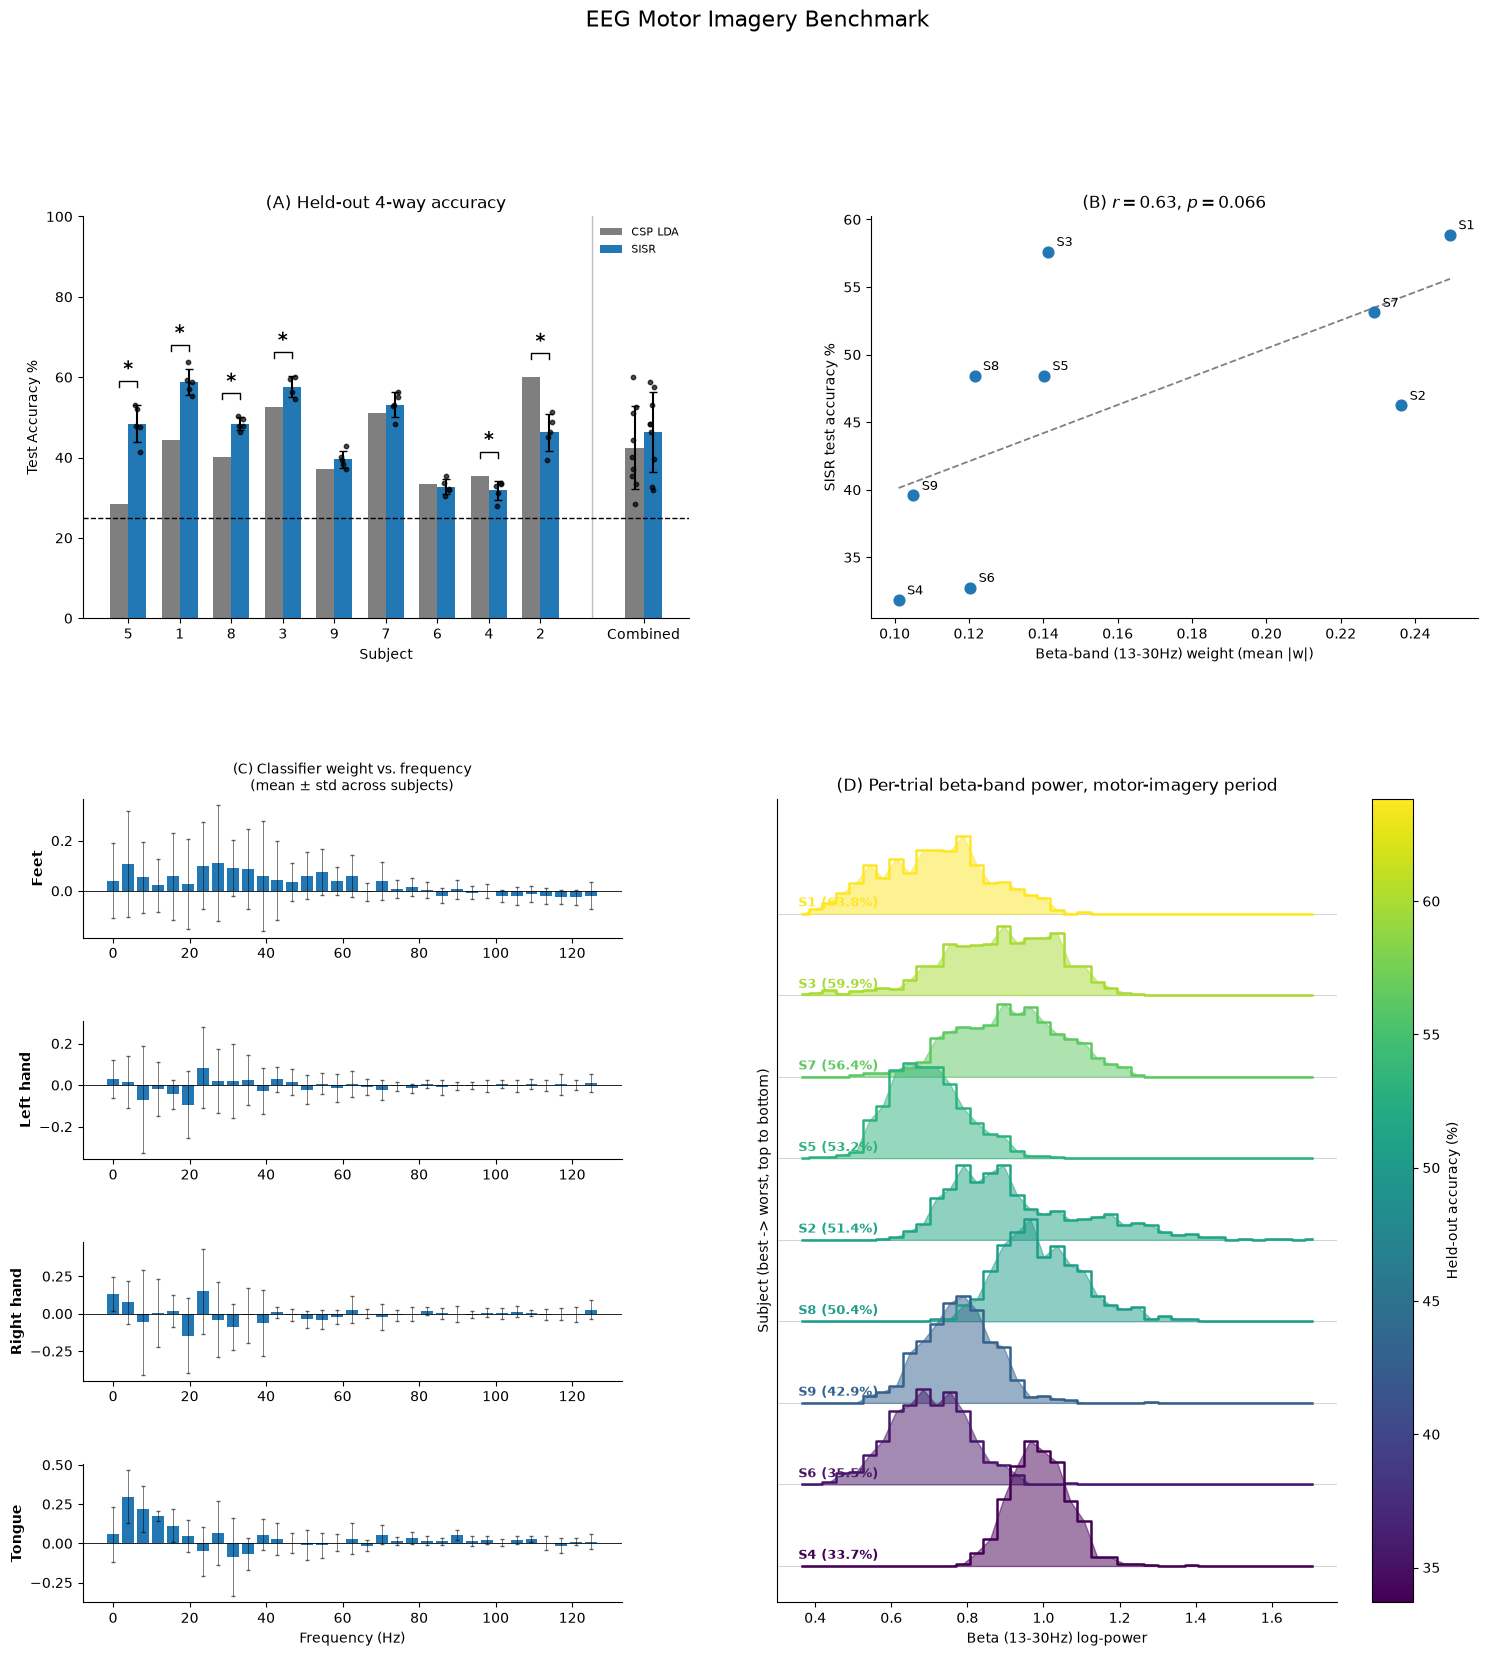

In [11]:
fig_path = fig5(baselines, mica, beta_cache)